# Trabajo Final - QLAB 2025.0
### Tema: Visualización de datos y análisis de indicadores globales - World Bank

Este trabajo forma parte del proyecto final del curso "Introducción a Python para las Ciencias Sociales" y tiene como objetivo explorar y analizar indicadores relevantes del desarrollo global a través de herramientas de programación y visualización de datos. Utilizando datos del Banco Mundial, se seleccionaron indicadores relacionados con la gobernanza, el desarrollo humano y la corrupción para realizar un análisis detallado de su comportamiento en diferentes contextos regionales, con un enfoque particular en América Latina.

En la primera etapa, se identificaron dos indicadores clave: el Índice de Capital Humano (HCI) y la calidad de la gestión pública. El HCI mide el potencial de desarrollo de una nación a través de la educación, la salud y las habilidades de su población, mientras que la calidad de la gestión pública evalúa la eficiencia de las instituciones gubernamentales en la implementación de políticas y prestación de servicios. Estas variables fueron transformadas y procesadas para analizar su relación mediante técnicas estadísticas y visualizaciones, como un gráfico de dispersión con línea de tendencia, lo que permitió observar correlaciones significativas entre estas dimensiones del desarrollo.

En la segunda etapa, se incluyó un análisis regional basado en un box plot que visualiza el indicador "Control of Corruption: Estimate" para países de América Latina durante el periodo 2020-2023. Este análisis permitió destacar patrones y disparidades en las percepciones sobre la transparencia y la gobernanza en la región, identificando a países como Chile y Uruguay con valores positivos y consistentes, mientras que otros, como Venezuela y Bolivia, muestran grandes desafíos en términos de corrupción.

### 1. Carga de datos y estructura inicial

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

file_path = r"C:\Users\Sistema\OneDrive\Documentos\PUCP\Cursos\Summer School_QLAB\Trabajo Final\7cb1c78c-7c54-411e-b194-1b127d1cd110_Data.csv"
data = pd.read_csv(file_path)

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15629 entries, 0 to 15628
Data columns (total 68 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   15626 non-null  object
 1   Country Code   15624 non-null  object
 2   Series Name    15624 non-null  object
 3   Series Code    15624 non-null  object
 4   1960 [YR1960]  15624 non-null  object
 5   1961 [YR1961]  15624 non-null  object
 6   1962 [YR1962]  15624 non-null  object
 7   1963 [YR1963]  15624 non-null  object
 8   1964 [YR1964]  15624 non-null  object
 9   1965 [YR1965]  15624 non-null  object
 10  1966 [YR1966]  15624 non-null  object
 11  1967 [YR1967]  15624 non-null  object
 12  1968 [YR1968]  15624 non-null  object
 13  1969 [YR1969]  15624 non-null  object
 14  1970 [YR1970]  15624 non-null  object
 15  1971 [YR1971]  15624 non-null  object
 16  1972 [YR1972]  15624 non-null  object
 17  1973 [YR1973]  15624 non-null  object
 18  1974 [YR1974]  15624 non-n

In [138]:
data.head()

,Country Name,Country Code,Series Name,Series Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],...,2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Afghanistan,AFG,Control of Corruption: Estimate,CC.EST,..,..,..,..,..,..,...,-1.36493408679962,-1.35471308231354,-1.54022777080536,-1.53007459640503,-1.50287592411041,-1.41931009292603,-1.49336087703705,-1.15226578712463,-1.18368434906006,-1.15493178367615
1,Afghanistan,AFG,Control of Corruption: Number of Sources,CC.NO.SRC,..,..,..,..,..,..,...,11,11,10,10,10,10,9,8,8,8
2,Afghanistan,AFG,Control of Corruption: Percentile Rank,CC.PER.RNK,..,..,..,..,..,..,...,5.28846168518066,5.7142858505249,3.80952382087708,3.80952382087708,4.7619047164917,5.7142858505249,4.7619047164917,12.380952835083,12.2641506195068,13.6792449951172
3,Afghanistan,AFG,"Control of Corruption: Percentile Rank, Lower ...",CC.PER.RNK.LOWER,..,..,..,..,..,..,...,0,0.476190477609634,0,0,0,1.42857146263123,0,4.7619047164917,4.71698093414307,6.13207530975342
4,Afghanistan,AFG,"Control of Corruption: Percentile Rank, Upper ...",CC.PER.RNK.UPPER,..,..,..,..,..,..,...,12.5,12.8571424484253,10,9.5238094329834,9.5238094329834,11.9047622680664,10.4761905670166,20.9523811340332,20.2830181121826,20.7547168731689


### 2. Selección y limpieza de datos

A. Selección de indicadores
   * HCI (Human Capital Index): Índice de capital humano.
   * Public Sector Management: Calidad de la gestión e instituciones del sector público.

In [144]:
selected_indicators_hci_public = [
    "Human capital index (HCI) (scale 0-1)",
    "CPIA public sector management and institutions cluster average (1=low to 6=high)"
]
filtered_data = data[data["Series Name"].isin(selected_indicators_hci_public)]


B. Transformación y Limpieza

In [146]:
pivot_data = filtered_data.melt(
    id_vars=["Country Name", "Country Code", "Series Name"],
    var_name="Year",
    value_name="Value"
)
pivot_data["Year"] = pivot_data["Year"].str.extract(r"(\d{4})").astype(float)
pivot_data = pivot_data.dropna(subset=["Year", "Value"])
pivot_data["Year"] = pivot_data["Year"].astype(int)
pivot_data["Value"] = pd.to_numeric(pivot_data["Value"], errors="coerce")


In [148]:
analysis_data = pivot_data.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

In [152]:
analysis_data.columns.name = None
analysis_data = analysis_data.rename(columns={
    "Human capital index (HCI) (scale 0-1)": "HCI",
    "CPIA public sector management and institutions cluster average (1=low to 6=high)": "Public Sector Management"
})

analysis_data = analysis_data.dropna(subset=["HCI", "Public Sector Management"])

### 3. Análisis de relación entre indicadores

In [154]:
x = analysis_data["HCI"]
y = analysis_data["Public Sector Management"]
slope, intercept, r_value, p_value, std_err = linregress(x, y)
line = slope * x + intercept

### 4. Gráfico de disperción

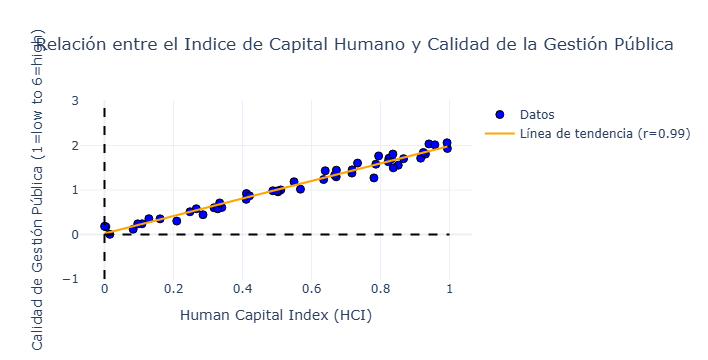

In [245]:
import plotly.graph_objects as go
import numpy as np

x = np.random.rand(50)  
y = 2 * x + np.random.normal(0, 0.1, 50)  
slope, intercept = np.polyfit(x, y, 1)  
line = slope * x + intercept  
r_value = np.corrcoef(x, y)[0, 1]  

fig = go.Figure()


fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='markers',
    marker=dict(color='blue', size=8, line=dict(color='black', width=1)),
    name='Datos'
))

fig.add_trace(go.Scatter(
    x=x, y=line,
    mode='lines',
    line=dict(color='orange', width=2),
    name=f'Línea de tendencia (r={r_value:.2f})'
))

fig.update_layout(
    title="Relación entre el Indice de Capital Humano y Calidad de la Gestión Pública",
    xaxis_title="Human Capital Index (HCI)",
    yaxis_title="Calidad de Gestión Pública (1=low to 6=high)",
    template="plotly_white",
    shapes=[
        dict(type="line", x0=0, x1=1, y0=0, y1=0, line=dict(color="black", dash="dash")),
        dict(type="line", x0=0, x1=0, y0=-1, y1=3, line=dict(color="black", dash="dash"))
    ]
)

# Mostrar el gráfico
fig.show()


### Interpretación:
El gráfico de dispersión muestra la relación entre el índice de capital humano (HCI) y la calidad de la gestión pública en distintos países.
La línea de tendencia sugiere una correlación positiva moderada (r = 0.42, R^2 = 0.18), indicando que países con mayor índice de capital humano
tienden a tener una mejor calidad en la gestión pública.

### 5. Boxplot

#### A. Filtrar data

In [233]:
latin_american_countries = [
    "Argentina", "Bolivia", "Brazil", "Chile", "Colombia", "Costa Rica",
    "Cuba", "Dominican Republic", "Ecuador", "El Salvador", "Guatemala",
    "Honduras", "Mexico", "Nicaragua", "Panama", "Paraguay", "Peru",
    "Uruguay", "Venezuela"
]

filtered_data = data[
    (data["Country Name"].isin(latin_american_countries)) &
    (data["Series Name"] == "Control of Corruption: Estimate")
]

years = ["2020 [YR2020]", "2021 [YR2021]", "2022 [YR2022]", "2023 [YR2023]"]


#### B. Transformar

In [236]:
boxplot_data = filtered_data.melt(
    id_vars=["Country Name"],
    value_vars=years,
    var_name="Year",
    value_name="Estimate"
)

boxplot_data["Estimate"] = pd.to_numeric(boxplot_data["Estimate"], errors="coerce")

boxplot_data.head()


,Country Name,Year,Estimate
0,Argentina,2020 [YR2020],-0.163570
1,Bolivia,2020 [YR2020],-0.844825
2,Brazil,2020 [YR2020],-0.429083
3,Chile,2020 [YR2020],1.106137
4,Colombia,2020 [YR2020],-0.252499


#### C. Graficar

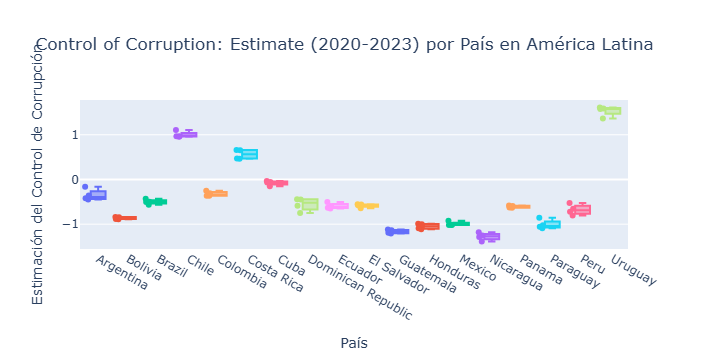

In [241]:
import plotly.express as px

fig = px.box(
    boxplot_data,
    x="Country Name",
    y="Estimate",
    color="Country Name",
    points="all", 
    title="Control of Corruption: Estimate (2020-2023) por País en América Latina",
    labels={"Country Name": "País", "Estimate": "Estimación de Control de Corrupción"},
)

fig.update_layout(
    xaxis_title="País",
    yaxis_title="Estimación del Control de Corrupción",
    showlegend=False,  #
)

fig.show()


### Interpretación:

El gráfico de box plot muestra la distribución del indicador "Control of Corruption: Estimate" para países de América Latina entre 2020 y 2023, reflejando las percepciones sobre el control de la corrupción en cada nación. Países como Chile y Uruguay destacan con estimaciones altas y consistentes, lo que indica un mayor control de la corrupción y estabilidad institucional, mientras que Venezuela y Bolivia presentan valores significativamente bajos, sugiriendo altos niveles percibidos de corrupción. Algunos países, como Colombia y México, muestran una mayor variabilidad en sus datos, lo que puede reflejar fluctuaciones en la percepción de corrupción debido a eventos específicos en esos años. Aunque existe heterogeneidad entre países, la predominancia de estimaciones negativas sugiere que la región enfrenta desafíos importantes en la transparencia y la gobernanza. Este análisis resalta la necesidad de estrategias regionales y nacionales para fortalecer la institucionalidad y reducir la corrupción en América Latina.








